In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/BNPL"

DATA_PATH = f"{PROJECT_PATH}/data"
MODEL_PATH = f"{PROJECT_PATH}/models"
OUTPUT_PATH = f"{PROJECT_PATH}/outputs"

print(PROJECT_PATH)

/content/drive/MyDrive/BNPL


In [3]:
import os

print("Project folder exists:", os.path.exists(PROJECT_PATH))
print("Data folder exists:", os.path.exists(DATA_PATH))
print("Model folder exists:", os.path.exists(MODEL_PATH))

Project folder exists: True
Data folder exists: True
Model folder exists: True


In [4]:
!pip install -q pandas numpy scikit-learn lightgbm joblib plotly

In [5]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
CONFIG = {
    "risk_low":              0.15,   # below 15% = Low Risk
    "risk_medium":           0.35,   # 15–35% = Medium Risk
                                     # above 35% = High Risk
    "base_credit_limit":    15000,
    "medium_credit_limit":   8000,
    "high_credit_limit":     3000,   # ← was 5000, now matches your function
}

CONFIG

{'risk_low': 0.15,
 'risk_medium': 0.35,
 'base_credit_limit': 15000,
 'medium_credit_limit': 8000,
 'high_credit_limit': 3000}

In [7]:
data = "/content/drive/MyDrive/BNPL/data/bnpl_v1/loan_working_copy.csv"
df = pd.read_csv(data)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (1048575, 29)


,loan_amnt,loan_term,int_rate,monthly_payment,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,...,mort_acc,num_accts_120_pd,pub_rec_bankruptcies,tax_liens,credit_limit,total_bal_ex_mort,hardship_flag,disbursement_method,debt_settlement_flag,loan_status
0,2500,36 months,13.56,84.92,C1,Chef,10+ years,RENT,55000.0,Not Verified,...,0,0,1,0,60124,16901,N,Cash,N,Current
1,30000,60 months,18.94,777.23,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,...,3,0,1,0,372872,99468,N,Cash,N,Current
2,5000,36 months,17.97,180.69,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,...,2,0,0,0,136927,11749,N,Cash,N,Current
3,4000,36 months,18.94,146.51,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,...,3,0,0,0,385183,36151,N,Cash,N,Current
4,30000,60 months,16.14,731.78,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,...,2,0,0,0,157548,29674,N,Cash,N,Current


In [8]:
data2 = "/content/drive/MyDrive/BNPL/data/bnpl_dataset (Buy Now, Pay Later (BNPL) Dataset) Practice.xlsx"

df2 = pd.read_excel(
    data2,
    sheet_name=25
)

print("Excel shape:", df2.shape)
print("\nColumns:")
print(df2.columns.tolist())

display(df2.head())

Excel shape: (50000, 15)

Columns:
['Transaction_ID', 'Customer_Age', 'Gender', 'Annual_Income', 'Credit_Score', 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount', 'Repayment_Status', 'Age 18-25 or Above 40', 'Income Below 40,000', 'Credit score>700', 'Low Income And Low Credit score', 'High Value Purchases (>1,500)', 'Low Credit Score or not']


,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status,Age 18-25 or Above 40,"Income Below 40,000",Credit score>700,Low Income And Low Credit score,"High Value Purchases (>1,500)",Low Credit Score or not
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted,Above 40,"Below 40,000",<700,Not Low Income And Low Credit Score,Not High Value Purchase,Low Credit Score
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time,Above 40,">=40,000",<700,Not Low Income And Low Credit Score,Not High Value Purchase,Low Credit Score
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time,Other,">=40,000",<700,Not Low Income And Low Credit Score,High Value Purchase (>1500),Not Low Credit Score
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time,Above 40,">=40,000",<700,Not Low Income And Low Credit Score,Not High Value Purchase,Low Credit Score
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time,18-25,"Below 40,000",<700,Not Low Income And Low Credit Score,High Value Purchase (>1500),Low Credit Score


ML LAYER

In [9]:
dataframe = df2.copy()

print("Dataset copied successfully.")
print("Shape:", dataframe.shape)

Dataset copied successfully.
Shape: (50000, 15)


In [10]:
#KEEP = ['customer_age','annual_income','credit_score','purchase_amount','gender','purchase_category','bnpl_provider']

#TARGET = 'repayment_status'

#DROP = ['transaction_id']

KEEP = [
    'Customer_Age',
    'Annual_Income',
    'Credit_Score',
    'Purchase_Amount',
    'Gender',
    'Purchase_Category',
    'BNPL_Provider'
]

TARGET = 'Repayment_Status'
DROP = ['Transaction_ID']

print("KEEP columns:")
print(KEEP)

print("\nTARGET:")
print(TARGET)

KEEP columns:
['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount', 'Gender', 'Purchase_Category', 'BNPL_Provider']

TARGET:
Repayment_Status


In [11]:
required_columns = KEEP + [TARGET] + DROP

missing_columns = [
    col for col in required_columns
    if col not in dataframe.columns
]

if len(missing_columns) == 0:
    print("All required columns are present.")
else:
    print("Missing columns:")
    print(missing_columns)

All required columns are present.


In [12]:
model_df = dataframe[KEEP + [TARGET]].copy()

print("Model dataset shape:", model_df.shape)
display(model_df.head())

print("Data types:")
print(model_df.dtypes)

print("\nMissing values:")
print(model_df.isnull().sum())

Model dataset shape: (50000, 8)


,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Gender,Purchase_Category,BNPL_Provider,Repayment_Status
0,56,32293,353,249,Male,Beauty,Sezzle,Defaulted
1,46,72774,354,188,Male,Groceries,Affirm,Paid On Time
2,32,82207,630,1610,Male,Travel,Sezzle,Paid On Time
3,60,92498,470,120,Male,Fashion,Sezzle,Paid On Time
4,25,32060,502,1849,Male,Travel,Klarna,Paid On Time


Data types:
Customer_Age          int64
Annual_Income         int64
Credit_Score          int64
Purchase_Amount       int64
Gender               object
Purchase_Category    object
BNPL_Provider        object
Repayment_Status     object
dtype: object

Missing values:
Customer_Age         0
Annual_Income        0
Credit_Score         0
Purchase_Amount      0
Gender               0
Purchase_Category    0
BNPL_Provider        0
Repayment_Status     0
dtype: int64


In [13]:
print("dataframe shape:", dataframe.shape)



print("\nColumns in dataframe:")

print(dataframe.columns.tolist())

print("\nFirst 5 rows:")

display(dataframe.head())

dataframe shape: (50000, 15)

Columns in dataframe:
['Transaction_ID', 'Customer_Age', 'Gender', 'Annual_Income', 'Credit_Score', 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount', 'Repayment_Status', 'Age 18-25 or Above 40', 'Income Below 40,000', 'Credit score>700', 'Low Income And Low Credit score', 'High Value Purchases (>1,500)', 'Low Credit Score or not']

First 5 rows:


,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status,Age 18-25 or Above 40,"Income Below 40,000",Credit score>700,Low Income And Low Credit score,"High Value Purchases (>1,500)",Low Credit Score or not
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted,Above 40,"Below 40,000",<700,Not Low Income And Low Credit Score,Not High Value Purchase,Low Credit Score
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time,Above 40,">=40,000",<700,Not Low Income And Low Credit Score,Not High Value Purchase,Low Credit Score
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time,Other,">=40,000",<700,Not Low Income And Low Credit Score,High Value Purchase (>1500),Not Low Credit Score
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time,Above 40,">=40,000",<700,Not Low Income And Low Credit Score,Not High Value Purchase,Low Credit Score
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time,18-25,"Below 40,000",<700,Not Low Income And Low Credit Score,High Value Purchase (>1500),Low Credit Score


In [14]:
print("Repayment Status Distribution:")
print(model_df[TARGET].value_counts())

print("\nPercentage Distribution:")
print(
    model_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Repayment Status Distribution:
Repayment_Status
Paid On Time    37612
Late Payment     8009
Defaulted        4379
Name: count, dtype: int64

Percentage Distribution:
Repayment_Status
Paid On Time    75.22
Late Payment    16.02
Defaulted        8.76
Name: proportion, dtype: float64


In [15]:
numeric_columns = [
    'Customer_Age',
    'Annual_Income',
    'Credit_Score',
    'Purchase_Amount'
]

categorical_columns = [
    'Gender',
    'Purchase_Category',
    'BNPL_Provider'
]

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount']

Categorical columns:
['Gender', 'Purchase_Category', 'BNPL_Provider']


In [16]:
X = model_df[KEEP].copy()
y = model_df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

X shape: (50000, 7)
y shape: (50000,)

X columns:
['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount', 'Gender', 'Purchase_Category', 'BNPL_Provider']

Target classes:
['Defaulted' 'Paid On Time' 'Late Payment']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (40000, 7)
Testing data: (10000, 7)

Training target distribution:
Repayment_Status
Paid On Time    30090
Late Payment     6407
Defaulted        3503
Name: count, dtype: int64

Testing target distribution:
Repayment_Status
Paid On Time    7522
Late Payment    1602
Defaulted        876
Name: count, dtype: int64


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns
        ),
        (
            ('numeric', StandardScaler(), numeric_columns)
        )
    ]
)

In [19]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (40000, 17)
Encoded testing shape: (10000, 17)


In [20]:
feature_names = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(feature_names))

print("\nEncoded features:")
print(feature_names)

Number of encoded features: 17

Encoded features:
['categorical__Gender_Female' 'categorical__Gender_Male'
 'categorical__Gender_Non-Binary' 'categorical__Purchase_Category_Beauty'
 'categorical__Purchase_Category_Electronics'
 'categorical__Purchase_Category_Fashion'
 'categorical__Purchase_Category_Groceries'
 'categorical__Purchase_Category_Home & Furniture'
 'categorical__Purchase_Category_Travel'
 'categorical__BNPL_Provider_Affirm' 'categorical__BNPL_Provider_Afterpay'
 'categorical__BNPL_Provider_Klarna' 'categorical__BNPL_Provider_Sezzle'
 'numeric__Customer_Age' 'numeric__Annual_Income' 'numeric__Credit_Score'
 'numeric__Purchase_Amount']


In [21]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(
    X_train_encoded,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [22]:
lr_predictions = lr_model.predict(X_test_encoded)

lr_probabilities = lr_model.predict_proba(X_test_encoded)

print("Classes:")
print(lr_model.classes_)

print("\nProbability shape:")
print(lr_probabilities.shape)

print("\nFirst 5 predictions:")
print(lr_predictions[:5])

Classes:
['Defaulted' 'Late Payment' 'Paid On Time']

Probability shape:
(10000, 3)

First 5 predictions:
['Paid On Time' 'Defaulted' 'Paid On Time' 'Paid On Time' 'Defaulted']


In [23]:
default_index = list(lr_model.classes_).index("Defaulted")

lr_default_probability = lr_probabilities[:, default_index]

print("Default class index:", default_index)

print("\nFirst 10 default probabilities:")
print(lr_default_probability[:10])

Default class index: 0

First 10 default probabilities:
[0.26119878 0.40307277 0.25992867 0.20302197 0.38553224 0.32102649
 0.24077897 0.49047934 0.27436715 0.45146177]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

Logistic Regression Accuracy: 0.5449

Classification Report:
              precision    recall  f1-score   support

   Defaulted       0.17      0.58      0.26       876
Late Payment       0.21      0.21      0.21      1602
Paid On Time       0.87      0.61      0.72      7522

    accuracy                           0.54     10000
   macro avg       0.41      0.47      0.40     10000
weighted avg       0.70      0.54      0.60     10000



In [25]:
cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=lr_model.classes_
)

print("Confusion Matrix:")
print(cm)

lr_auc = roc_auc_score(
    y_test,
    lr_probabilities,
    multi_class='ovr'
)

print("Logistic Regression ROC-AUC:", lr_auc)

Confusion Matrix:
[[ 507  177  192]
 [ 758  342  502]
 [1785 1137 4600]]
Logistic Regression ROC-AUC: 0.6783671000513655


In [26]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=20,
    min_child_samples=50,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train_encoded, y_train,
    eval_set=[(X_test_encoded, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
print("LightGBM trained successfully.")

LightGBM trained successfully.


In [27]:
lgb_predictions  = lgb_model.predict(X_test_encoded)
lgb_probabilities = lgb_model.predict_proba(X_test_encoded)

# Extract default probability (same pattern as your LR code)
lgb_default_index = list(lgb_model.classes_).index("Defaulted")
lgb_default_probability = lgb_probabilities[:, lgb_default_index]

print("LightGBM Accuracy:", accuracy_score(y_test, lgb_predictions))
print()
print(classification_report(y_test, lgb_predictions))

lgb_auc = roc_auc_score(y_test, lgb_probabilities, multi_class='ovr')
print("LightGBM ROC-AUC:", lgb_auc)

LightGBM Accuracy: 0.5252

              precision    recall  f1-score   support

   Defaulted       0.19      0.53      0.28       876
Late Payment       0.21      0.37      0.27      1602
Paid On Time       0.89      0.56      0.68      7522

    accuracy                           0.53     10000
   macro avg       0.43      0.49      0.41     10000
weighted avg       0.72      0.53      0.58     10000

LightGBM ROC-AUC: 0.6900754039149971


In [28]:
print("MODEL COMPARISON")
print(f"Logistic Regression ROC-AUC : {lr_auc:.4f}")
print(f"LightGBM ROC-AUC            : {lgb_auc:.4f}")
print(f"Winner: {'LightGBM' if lgb_auc > lr_auc else 'Logistic Regression'}")

# Save both models
import joblib
joblib.dump(lgb_model,    f"{MODEL_PATH}/lgb_model.pkl")
joblib.dump(lr_model,     f"{MODEL_PATH}/lr_model.pkl")
joblib.dump(preprocessor, f"{MODEL_PATH}/preprocessor.pkl")
print("Models saved.")

MODEL COMPARISON
Logistic Regression ROC-AUC : 0.6784
LightGBM ROC-AUC            : 0.6901
Winner: LightGBM
Models saved.


In [29]:
# LOGISTIC REGRESSION - DETAILED METRICS

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision_macro = precision_score(
    y_test,
    lr_predictions,
    average="macro",
    zero_division=0
)

lr_recall_macro = recall_score(
    y_test,
    lr_predictions,
    average="macro",
    zero_division=0
)

lr_f1_macro = f1_score(
    y_test,
    lr_predictions,
    average="macro",
    zero_division=0
)

print("LOGISTIC REGRESSION")
print("-------------------")
print(f"Accuracy          : {lr_accuracy:.4f}")
print(f"Macro Precision   : {lr_precision_macro:.4f}")
print(f"Macro Recall      : {lr_recall_macro:.4f}")
print(f"Macro F1 Score    : {lr_f1_macro:.4f}")
print(f"ROC-AUC           : {lr_auc:.4f}")

LOGISTIC REGRESSION
-------------------
Accuracy          : 0.5449
Macro Precision   : 0.4139
Macro Recall      : 0.4679
Macro F1 Score    : 0.3954
ROC-AUC           : 0.6784


In [30]:
# LOGISTIC REGRESSION - EXPLAINABILITY

lr_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[default_index]
})

lr_coefficients["Absolute_Importance"] = (
    lr_coefficients["Coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "Absolute_Importance",
    ascending=False
)

display(
    lr_coefficients.head(15)
)

,Feature,Coefficient,Absolute_Importance
15,numeric__Credit_Score,-0.389355,0.389355
14,numeric__Annual_Income,-0.199075,0.199075
7,categorical__Purchase_Category_Home & Furniture,-0.103578,0.103578
9,categorical__BNPL_Provider_Affirm,-0.040350,0.040350
16,numeric__Purchase_Amount,0.038994,0.038994
11,categorical__BNPL_Provider_Klarna,-0.038060,0.038060
5,categorical__Purchase_Category_Fashion,0.036186,0.036186
1,categorical__Gender_Male,-0.035296,0.035296
0,categorical__Gender_Female,-0.034565,0.034565
6,categorical__Purchase_Category_Groceries,-0.021527,0.021527


In [31]:
lgb_accuracy = accuracy_score(
    y_test,
    lgb_predictions
)

lgb_precision_macro = precision_score(
    y_test,
    lgb_predictions,
    average="macro",
    zero_division=0
)

lgb_recall_macro = recall_score(
    y_test,
    lgb_predictions,
    average="macro",
    zero_division=0
)

lgb_f1_macro = f1_score(
    y_test,
    lgb_predictions,
    average="macro",
    zero_division=0
)

lgb_auc = roc_auc_score(y_test, lgb_probabilities, multi_class='ovr')

print("LIGHTGBM")
print("--------")
print(f"Accuracy          : {lgb_accuracy:.4f}")
print(f"Macro Precision   : {lgb_precision_macro:.4f}")
print(f"Macro Recall      : {lgb_recall_macro:.4f}")
print(f"Macro F1 Score    : {lgb_f1_macro:.4f}")
print(f"ROC-AUC           : {lgb_auc:.4f}")

LIGHTGBM
--------
Accuracy          : 0.5252
Macro Precision   : 0.4295
Macro Recall      : 0.4862
Macro F1 Score    : 0.4109
ROC-AUC           : 0.6901


In [32]:
# LIGHTGBM - FEATURE IMPORTANCE

import joblib

lgb_model = joblib.load(f"{MODEL_PATH}/lgb_model.pkl")

lgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgb_model.feature_importances_
})

lgb_feature_importance = (
    lgb_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    lgb_feature_importance.head(15)
)

,Feature,Importance
0,numeric__Purchase_Amount,3885
1,numeric__Annual_Income,3745
2,numeric__Credit_Score,3628
3,numeric__Customer_Age,2674
4,categorical__Gender_Male,299
5,categorical__BNPL_Provider_Klarna,276
6,categorical__BNPL_Provider_Sezzle,266
7,categorical__BNPL_Provider_Affirm,261
8,categorical__Gender_Female,257
9,categorical__BNPL_Provider_Afterpay,255


In [33]:
# FINAL MODEL COMPARISON

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM"
    ],
    "Accuracy": [
        lr_accuracy,
        lgb_accuracy
    ],
    "Macro_Precision": [
        lr_precision_macro,
        lgb_precision_macro
    ],
    "Macro_Recall": [
        lr_recall_macro,
        lgb_recall_macro
    ],
    "Macro_F1": [
        lr_f1_macro,
        lgb_f1_macro
    ],
    "ROC_AUC": [
        lr_auc,
        lgb_auc
    ]
})

display(
    model_comparison.round(4)
)

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,ROC_AUC
0,Logistic Regression,0.5449,0.4139,0.4679,0.3954,0.6784
1,LightGBM,0.5252,0.4295,0.4862,0.4109,0.6901


In [34]:
# DEPLOYED DEFAULT PROBABILITY

default_probability = lgb_default_probability.copy()

print("Default probability created.")

print("\nFirst 10 default probabilities:")
print(default_probability[:10])

Default probability created.

First 10 default probabilities:
[0.10463714 0.32648586 0.118826   0.10138955 0.50615338 0.28789147
 0.15299928 0.65003723 0.39145117 0.36136517]


In [35]:
# FINAL RISK CONFIGURATION

FINAL_RISK_CONFIG = {
    "risk_low": 0.15,
    "risk_medium": 0.35,
    "base_credit_limit": 15000,
    "medium_credit_limit": 8000,
    "high_credit_limit": 5000
}

FINAL_RISK_CONFIG

{'risk_low': 0.15,
 'risk_medium': 0.35,
 'base_credit_limit': 15000,
 'medium_credit_limit': 8000,
 'high_credit_limit': 5000}

In [36]:
def classify_risk(default_probability):

    if default_probability < FINAL_RISK_CONFIG["risk_low"]:
        return "LOW"

    elif default_probability < FINAL_RISK_CONFIG["risk_medium"]:
        return "MEDIUM"

    else:
        return "HIGH"

In [37]:
print(classify_risk(0.10))
print(classify_risk(0.25))
print(classify_risk(0.50))

LOW
MEDIUM
HIGH


In [38]:
risk_levels = np.array([
    classify_risk(probability)
    for probability in default_probability
])

print(
    pd.Series(risk_levels).value_counts()
)

MEDIUM    3604
LOW       3554
HIGH      2842
Name: count, dtype: int64


In [39]:
def calculate_credit_limit(
    annual_income,
    risk
):

    # Prototype income-based base limit
    base_limit = (annual_income / 12) * 0.20

    if risk == "LOW":
        risk_factor = 1.00

    elif risk == "MEDIUM":
        risk_factor = 0.60

    else:
        risk_factor = 0.30

    limit = base_limit * risk_factor

    # Keep prototype limit within practical demo bounds
    limit = max(1000, min(limit, 15000))

    return round(limit, 0)

In [40]:
# FINAL ML OUTPUT TABLE

ml_results = X_test.copy()

ml_results["Actual_Repayment_Status"] = y_test.values

ml_results["Default_Probability"] = default_probability

ml_results["Risk_Level"] = risk_levels

ml_results["Recommended_Credit_Limit"] = [
    calculate_credit_limit(
        income,
        risk
    )
    for income, risk in zip(
        ml_results["Annual_Income"],
        ml_results["Risk_Level"]
    )
]

display(
    ml_results.head(10)
)

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Gender,Purchase_Category,BNPL_Provider,Actual_Repayment_Status,Default_Probability,Risk_Level,Recommended_Credit_Limit
32905,26,56279,630,189,Male,Groceries,Affirm,Paid On Time,0.104637,LOW,1000.0
48257,51,55969,501,1993,Female,Travel,Afterpay,Paid On Time,0.326486,MEDIUM,1000.0
39275,43,72901,595,213,Male,Groceries,Sezzle,Paid On Time,0.118826,LOW,1215.0
40578,27,73607,691,94,Male,Fashion,Afterpay,Paid On Time,0.101390,LOW,1227.0
47210,64,28729,536,150,Female,Beauty,Affirm,Paid On Time,0.506153,HIGH,1000.0
41485,27,30366,633,21,Male,Groceries,Afterpay,Defaulted,0.287891,MEDIUM,1000.0
46963,58,69853,630,295,Male,Beauty,Sezzle,Paid On Time,0.152999,MEDIUM,1000.0
26721,48,27374,462,147,Female,Fashion,Sezzle,Late Payment,0.650037,HIGH,1000.0
25629,61,53937,567,54,Female,Home & Furniture,Klarna,Paid On Time,0.391451,HIGH,1000.0
22574,27,79195,333,130,Male,Beauty,Afterpay,Paid On Time,0.361365,HIGH,1000.0


In [41]:
# TOP LIGHTGBM RISK FACTORS

top_risk_factors = (
    lgb_feature_importance
    .head(10)
    .copy()
)

display(top_risk_factors)

top_5_risk_factors = (
    lgb_feature_importance
    .head(5)["Feature"]
    .tolist()
)

print("Top 5 risk factors:")

for i, feature in enumerate(
    top_5_risk_factors,
    start=1
):
    print(f"{i}. {feature}")

,Feature,Importance
0,numeric__Purchase_Amount,3885
1,numeric__Annual_Income,3745
2,numeric__Credit_Score,3628
3,numeric__Customer_Age,2674
4,categorical__Gender_Male,299
5,categorical__BNPL_Provider_Klarna,276
6,categorical__BNPL_Provider_Sezzle,266
7,categorical__BNPL_Provider_Affirm,261
8,categorical__Gender_Female,257
9,categorical__BNPL_Provider_Afterpay,255


Top 5 risk factors:
1. numeric__Purchase_Amount
2. numeric__Annual_Income
3. numeric__Credit_Score
4. numeric__Customer_Age
5. categorical__Gender_Male


In [42]:
# CELL 44 — REPLACE ENTIRE CELL WITH THIS

import joblib

preprocessor  = joblib.load(f"{MODEL_PATH}/preprocessor.pkl")
lr_model      = joblib.load(f"{MODEL_PATH}/lr_model.pkl")
lgb_model     = joblib.load(f"{MODEL_PATH}/lgb_model.pkl")
kmeans        = joblib.load(f"{MODEL_PATH}/kmeans.pkl")
cluster_scaler= joblib.load(f"{MODEL_PATH}/kmeans_scaler.pkl")
SEGMENT_LABELS= joblib.load(f"{MODEL_PATH}/segment_labels.pkl")
top_5_risk_factors = joblib.load(f"{MODEL_PATH}/top_risk_factors.pkl")

default_index     = list(lr_model.classes_).index("Defaulted")
lgb_default_index = list(lgb_model.classes_).index("Defaulted")

CLUSTER_FEATURES = ['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount']

def predict_customer(customer_data: dict) -> dict:
    customer_df      = pd.DataFrame([customer_data])
    customer_encoded = preprocessor.transform(customer_df[KEEP])

    # LightGBM — deployed model
    lgb_probs    = lgb_model.predict_proba(customer_encoded)[0]
    lgb_default  = float(lgb_probs[lgb_default_index])

    # LR — baseline
    lr_probs     = lr_model.predict_proba(customer_encoded)[0]
    lr_default   = float(lr_probs[default_index])

    # Risk outputs
    risk         = classify_risk(lgb_default)
    credit_limit = calculate_credit_limit(customer_data["Annual_Income"], risk)
    risk_score   = round(
        lgb_default * 50 +
        (1 - customer_data["Credit_Score"] / 850) * 30 +
        min((customer_data["Purchase_Amount"] / max(customer_data["Annual_Income"], 1)) * 100, 20),
        1
    )

    # K-Means segment
    cluster_input  = [[
        customer_data["Customer_Age"],
        customer_data["Annual_Income"],
        customer_data["Credit_Score"],
        customer_data["Purchase_Amount"]
    ]]
    segment_num    = kmeans.predict(cluster_scaler.transform(cluster_input))[0]
    segment_label  = SEGMENT_LABELS[segment_num]

    return {
        "default_probability":      lgb_default,
        "lr_default_probability":   lr_default,
        "risk_level":               risk,
        "risk_score":               risk_score,
        "credit_limit":             credit_limit,
        "recommended_credit_limit": credit_limit,   # alias for compatibility
        "segment":                  segment_label,
        "top_risk_factors":         top_5_risk_factors,
    }

print("predict_customer() loaded and ready.")

predict_customer() loaded and ready.


In [43]:
# SAVE FINAL ML CONFIGURATION

joblib.dump(
    FINAL_RISK_CONFIG,
    f"{MODEL_PATH}/final_risk_config.pkl"
)

joblib.dump(
    feature_names,
    f"{MODEL_PATH}/feature_names.pkl"
)

joblib.dump(
    top_5_risk_factors,
    f"{MODEL_PATH}/top_risk_factors.pkl"
)

print("Final ML configuration saved.")

Final ML configuration saved.


In [44]:
print("Saved ML files:")

ml_files = [
    "lr_model.pkl",
    "lgb_model.pkl",
    "preprocessor.pkl",
    "final_risk_config.pkl",
    "feature_names.pkl",
    "top_risk_factors.pkl"
]

for file_name in ml_files:

    path = f"{MODEL_PATH}/{file_name}"

    print(
        f"{file_name}:",
        "EXISTS" if os.path.exists(path)
        else "MISSING"
    )

Saved ML files:
lr_model.pkl: EXISTS
lgb_model.pkl: EXISTS
preprocessor.pkl: EXISTS
final_risk_config.pkl: EXISTS
feature_names.pkl: EXISTS
top_risk_factors.pkl: EXISTS


FEATURE ENGINEERING

In [45]:
# LAYER 2 - FEATURE ENGINEERING

feature_df = dataframe.copy()

print("Feature engineering dataset shape:", feature_df.shape)
print("\nOriginal columns:")
print(feature_df.columns.tolist())

Feature engineering dataset shape: (50000, 15)

Original columns:
['Transaction_ID', 'Customer_Age', 'Gender', 'Annual_Income', 'Credit_Score', 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount', 'Repayment_Status', 'Age 18-25 or Above 40', 'Income Below 40,000', 'Credit score>700', 'Low Income And Low Credit score', 'High Value Purchases (>1,500)', 'Low Credit Score or not']


In [46]:
required_raw_features = [
    'Customer_Age',
    'Annual_Income',
    'Credit_Score',
    'Purchase_Amount',
    'Gender',
    'Purchase_Category',
    'BNPL_Provider',
    'Repayment_Status'
]

missing_raw_features = [
    col for col in required_raw_features
    if col not in feature_df.columns
]

if len(missing_raw_features) == 0:
    print("All required raw features are present.")
else:
    print("Missing features:")
    print(missing_raw_features)

All required raw features are present.


In [47]:
feature_df["Age_Risk_Flag"] = np.where(
    (feature_df["Customer_Age"] >= 18) &
    (feature_df["Customer_Age"] <= 25) |
    (feature_df["Customer_Age"] > 40),
    1,
    0
)

print(
    feature_df[
        ["Customer_Age", "Age_Risk_Flag"]
    ].head(10)
)

   Customer_Age  Age_Risk_Flag
0            56              1
1            46              1
2            32              0
3            60              1
4            25              1
5            38              0
6            56              1
7            36              0
8            40              0
9            28              0


In [48]:
feature_df["Low_Income_Flag"] = np.where(
    feature_df["Annual_Income"] < 40000,
    1,
    0
)

print(
    feature_df[
        ["Annual_Income", "Low_Income_Flag"]
    ].head(10)
)

   Annual_Income  Low_Income_Flag
0          32293                1
1          72774                0
2          82207                0
3          92498                0
4          32060                1
5          94833                0
6          89772                0
7          82341                0
8          80517                0
9         108929                0


In [49]:
feature_df["High_Credit_Score_Flag"] = np.where(
    feature_df["Credit_Score"] > 700,
    1,
    0
)

print(
    feature_df[
        ["Credit_Score", "High_Credit_Score_Flag"]
    ].head(10)
)

   Credit_Score  High_Credit_Score_Flag
0           353                       0
1           354                       0
2           630                       0
3           470                       0
4           502                       0
5           779                       1
6           403                       0
7           731                       1
8           669                       0
9           359                       0


In [50]:
feature_df["Low_Income_Low_Credit_Flag"] = np.where(
    (feature_df["Annual_Income"] < 40000) &
    (feature_df["Credit_Score"] <= 700),
    1,
    0
)

print(
    feature_df[
        [
            "Annual_Income",
            "Credit_Score",
            "Low_Income_Low_Credit_Flag"
        ]
    ].head(10)
)

   Annual_Income  Credit_Score  Low_Income_Low_Credit_Flag
0          32293           353                           1
1          72774           354                           0
2          82207           630                           0
3          92498           470                           0
4          32060           502                           1
5          94833           779                           0
6          89772           403                           0
7          82341           731                           0
8          80517           669                           0
9         108929           359                           0


In [51]:
feature_df["High_Value_Purchase_Flag"] = np.where(
    feature_df["Purchase_Amount"] > 1500,
    1,
    0
)

print(
    feature_df[
        [
            "Purchase_Amount",
            "High_Value_Purchase_Flag"
        ]
    ].head(10)
)

   Purchase_Amount  High_Value_Purchase_Flag
0              249                         0
1              188                         0
2             1610                         1
3              120                         0
4             1849                         1
5             1112                         0
6              418                         0
7             2117                         1
8              286                         0
9              244                         0


In [52]:
feature_df["Low_Credit_Score_Flag"] = np.where(
    feature_df["Credit_Score"] <= 700,
    1,
    0
)

print(
    feature_df[
        [
            "Credit_Score",
            "Low_Credit_Score_Flag"
        ]
    ].head(10)
)

   Credit_Score  Low_Credit_Score_Flag
0           353                      1
1           354                      1
2           630                      1
3           470                      1
4           502                      1
5           779                      0
6           403                      1
7           731                      0
8           669                      1
9           359                      1


In [53]:
feature_df["Purchase_Income_Ratio"] = (
    feature_df["Purchase_Amount"] /
    feature_df["Annual_Income"]
)

print(
    feature_df[
        [
            "Purchase_Amount",
            "Annual_Income",
            "Purchase_Income_Ratio"
        ]
    ].head(10)
)

   Purchase_Amount  Annual_Income  Purchase_Income_Ratio
0              249          32293               0.007711
1              188          72774               0.002583
2             1610          82207               0.019585
3              120          92498               0.001297
4             1849          32060               0.057673
5             1112          94833               0.011726
6              418          89772               0.004656
7             2117          82341               0.025710
8              286          80517               0.003552
9              244         108929               0.002240


In [54]:
feature_df["Risk_Factor_Count"] = (
    feature_df["Age_Risk_Flag"] +
    feature_df["Low_Income_Flag"] +
    (1 - feature_df["High_Credit_Score_Flag"]) +
    feature_df["Low_Income_Low_Credit_Flag"] +
    feature_df["High_Value_Purchase_Flag"] +
    feature_df["Low_Credit_Score_Flag"]
)

print(
    feature_df[
        [
            "Age_Risk_Flag",
            "Low_Income_Flag",
            "High_Credit_Score_Flag",
            "Low_Income_Low_Credit_Flag",
            "High_Value_Purchase_Flag",
            "Low_Credit_Score_Flag",
            "Risk_Factor_Count"
        ]
    ].head(10)
)

   Age_Risk_Flag  Low_Income_Flag  High_Credit_Score_Flag  \
0              1                1                       0   
1              1                0                       0   
2              0                0                       0   
3              1                0                       0   
4              1                1                       0   
5              0                0                       1   
6              1                0                       0   
7              0                0                       1   
8              0                0                       0   
9              0                0                       0   

   Low_Income_Low_Credit_Flag  High_Value_Purchase_Flag  \
0                           1                         0   
1                           0                         0   
2                           0                         1   
3                           0                         0   
4                           1    

In [55]:
engineered_features = [
    "Age_Risk_Flag",
    "Low_Income_Flag",
    "High_Credit_Score_Flag",
    "Low_Income_Low_Credit_Flag",
    "High_Value_Purchase_Flag",
    "Low_Credit_Score_Flag",
    "Purchase_Income_Ratio",
    "Risk_Factor_Count"
]

print("Number of engineered features:", len(engineered_features))

print("\nEngineered features:")
for i, feature in enumerate(engineered_features, start=1):
    print(f"{i}. {feature}")

Number of engineered features: 8

Engineered features:
1. Age_Risk_Flag
2. Low_Income_Flag
3. High_Credit_Score_Flag
4. Low_Income_Low_Credit_Flag
5. High_Value_Purchase_Flag
6. Low_Credit_Score_Flag
7. Purchase_Income_Ratio
8. Risk_Factor_Count


In [56]:
display(
    feature_df[
        [
            "Customer_Age",
            "Annual_Income",
            "Credit_Score",
            "Purchase_Amount"
        ] + engineered_features
    ].head(15)
)

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Age_Risk_Flag,Low_Income_Flag,High_Credit_Score_Flag,Low_Income_Low_Credit_Flag,High_Value_Purchase_Flag,Low_Credit_Score_Flag,Purchase_Income_Ratio,Risk_Factor_Count
0,56,32293,353,249,1,1,0,1,0,1,0.007711,5
1,46,72774,354,188,1,0,0,0,0,1,0.002583,3
2,32,82207,630,1610,0,0,0,0,1,1,0.019585,3
3,60,92498,470,120,1,0,0,0,0,1,0.001297,3
4,25,32060,502,1849,1,1,0,1,1,1,0.057673,6
5,38,94833,779,1112,0,0,1,0,0,0,0.011726,0
6,56,89772,403,418,1,0,0,0,0,1,0.004656,3
7,36,82341,731,2117,0,0,1,0,1,0,0.025710,1
8,40,80517,669,286,0,0,0,0,0,1,0.003552,2
9,28,108929,359,244,0,0,0,0,0,1,0.002240,2


In [57]:
print("Missing values in engineered features:")

print(
    feature_df[engineered_features]
    .isnull()
    .sum()
)

print(
    "\nTotal missing engineered values:",
    feature_df[engineered_features]
    .isnull()
    .sum()
    .sum()
)

Missing values in engineered features:
Age_Risk_Flag                 0
Low_Income_Flag               0
High_Credit_Score_Flag        0
Low_Income_Low_Credit_Flag    0
High_Value_Purchase_Flag      0
Low_Credit_Score_Flag         0
Purchase_Income_Ratio         0
Risk_Factor_Count             0
dtype: int64

Total missing engineered values: 0


In [58]:
print("Binary feature distributions:\n")

for feature in engineered_features[:6]:
    print(
        feature,
        ":",
        feature_df[feature].value_counts().to_dict()
    )

print("\nPurchase/Income Ratio:")
print(
    feature_df["Purchase_Income_Ratio"].describe()
)

print("\nRisk Factor Count:")
print(
    feature_df["Risk_Factor_Count"].value_counts().sort_index()
)

Binary feature distributions:

Age_Risk_Flag : {1: 33854, 0: 16146}
Low_Income_Flag : {0: 39943, 1: 10057}
High_Credit_Score_Flag : {0: 36522, 1: 13478}
Low_Income_Low_Credit_Flag : {0: 42705, 1: 7295}
High_Value_Purchase_Flag : {0: 43126, 1: 6874}
Low_Credit_Score_Flag : {1: 36522, 0: 13478}

Purchase/Income Ratio:
count    50000.000000
mean         0.010129
std          0.015531
min          0.000167
25%          0.001775
50%          0.003555
75%          0.011606
max          0.147034
Name: Purchase_Income_Ratio, dtype: float64

Risk Factor Count:
Risk_Factor_Count
0     2968
1     7501
2    10845
3    18704
4     4763
5     4545
6      674
Name: count, dtype: int64


In [59]:
age_check = pd.crosstab(
    feature_df["Age_Risk_Flag"],
    feature_df["Age 18-25 or Above 40"]
)

display(age_check)

income_check = pd.crosstab(
    feature_df["Low_Income_Flag"],
    feature_df["Income Below 40,000"]
)

display(income_check)

credit_check = pd.crosstab(
    feature_df["High_Credit_Score_Flag"],
    feature_df["Credit score>700"]
)

display(credit_check)

combined_check = pd.crosstab(
    feature_df["Low_Income_Low_Credit_Flag"],
    feature_df["Low Income And Low Credit score"]
)

display(combined_check)

purchase_check = pd.crosstab(
    feature_df["High_Value_Purchase_Flag"],
    feature_df["High Value Purchases (>1,500)"]
)

display(purchase_check)

low_credit_check = pd.crosstab(
    feature_df["Low_Credit_Score_Flag"],
    feature_df["Low Credit Score or not"]
)

display(low_credit_check)

Age 18-25 or Above 40,18-25,Above 40,Other
Age_Risk_Flag,,,
0,0,0,16146
1,8421,25433,0


"Income Below 40,000",">=40,000","Below 40,000"
Low_Income_Flag,,
0,39943,0
1,0,10057


Credit score>700,<700,>700
High_Credit_Score_Flag,,
0,36522,0
1,0,13478


Low Income And Low Credit score,Low Income And Low Credit Score,Not Low Income And Low Credit Score
Low_Income_Low_Credit_Flag,,
0,0,42705
1,1287,6008


"High Value Purchases (>1,500)",High Value Purchase (>1500),Not High Value Purchase
High_Value_Purchase_Flag,,
0,0,43126
1,6874,0


Low Credit Score or not,Low Credit Score,Not Low Credit Score
Low_Credit_Score_Flag,,
0,0,13478
1,25707,10815


In [60]:
layer2_features = [
    "Customer_Age",
    "Annual_Income",
    "Credit_Score",
    "Purchase_Amount",
    "Gender",
    "Purchase_Category",
    "BNPL_Provider"
] + engineered_features

layer2_df = feature_df[
    layer2_features + ["Repayment_Status"]
].copy()

print("Layer 2 dataset shape:", layer2_df.shape)

display(layer2_df.head())

Layer 2 dataset shape: (50000, 16)


,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Gender,Purchase_Category,BNPL_Provider,Age_Risk_Flag,Low_Income_Flag,High_Credit_Score_Flag,Low_Income_Low_Credit_Flag,High_Value_Purchase_Flag,Low_Credit_Score_Flag,Purchase_Income_Ratio,Risk_Factor_Count,Repayment_Status
0,56,32293,353,249,Male,Beauty,Sezzle,1,1,0,1,0,1,0.007711,5,Defaulted
1,46,72774,354,188,Male,Groceries,Affirm,1,0,0,0,0,1,0.002583,3,Paid On Time
2,32,82207,630,1610,Male,Travel,Sezzle,0,0,0,0,1,1,0.019585,3,Paid On Time
3,60,92498,470,120,Male,Fashion,Sezzle,1,0,0,0,0,1,0.001297,3,Paid On Time
4,25,32060,502,1849,Male,Travel,Klarna,1,1,0,1,1,1,0.057673,6,Paid On Time


In [61]:
print("Layer 2 Feature Engineering Summary")
print("=" * 45)

print("Raw model features:", 7)
print("Engineered features:", len(engineered_features))
print("Target: Repayment_Status")
print("Total model columns:", len(layer2_df.columns))

print("\nEngineered features:")
print(engineered_features)

print("\nMissing values:")
print(
    layer2_df.isnull().sum().sum()
)

Layer 2 Feature Engineering Summary
Raw model features: 7
Engineered features: 8
Target: Repayment_Status
Total model columns: 16

Engineered features:
['Age_Risk_Flag', 'Low_Income_Flag', 'High_Credit_Score_Flag', 'Low_Income_Low_Credit_Flag', 'High_Value_Purchase_Flag', 'Low_Credit_Score_Flag', 'Purchase_Income_Ratio', 'Risk_Factor_Count']

Missing values:
0


In [62]:
LAYER2_PATH = "/content/drive/MyDrive/BNPL/outputs"

os.makedirs(LAYER2_PATH, exist_ok=True)

layer2_df.to_csv(
    f"{LAYER2_PATH}/bnpl_layer2_features.csv",
    index=False
)

print("Layer 2 dataset saved.")

Layer 2 dataset saved.


In [63]:
joblib.dump(
    engineered_features,
    f"{MODEL_PATH}/engineered_features.pkl"
)

joblib.dump(
    layer2_features,
    f"{MODEL_PATH}/layer2_features.pkl"
)

print("✓ Layer 2 feature lists saved.")

✓ Layer 2 feature lists saved.


TRUST/FRAUD LAYER (START)

In [64]:
import pandas as pd
import numpy as np

print("Libraries imported successfully")

print("Dataset shape:", dataframe.shape)

print("\nColumns:")
print(dataframe.columns.tolist())

Libraries imported successfully
Dataset shape: (50000, 15)

Columns:
['Transaction_ID', 'Customer_Age', 'Gender', 'Annual_Income', 'Credit_Score', 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount', 'Repayment_Status', 'Age 18-25 or Above 40', 'Income Below 40,000', 'Credit score>700', 'Low Income And Low Credit score', 'High Value Purchases (>1,500)', 'Low Credit Score or not']


In [65]:
fraud_df = dataframe.copy()

print("Fraud dataset shape:", fraud_df.shape)

np.random.seed(42)

print("Random seed set to 42")

fraud_df["Customer_ID"] = [
    f"CUST_{i:05d}"
    for i in np.random.randint(
        1,
        10001,
        size=len(fraud_df)
    )
]

print(
    fraud_df["Customer_ID"].head()
)

print(
    "\nUnique simulated customers:",
    fraud_df["Customer_ID"].nunique()
)

Fraud dataset shape: (50000, 15)
Random seed set to 42
0    CUST_07271
1    CUST_00861
2    CUST_05391
3    CUST_05192
4    CUST_05735
Name: Customer_ID, dtype: object

Unique simulated customers: 9924


In [66]:
fraud_df["Device_ID"] = [
    f"DEV_{i:04d}"
    for i in np.random.randint(
        1,
        3001,
        size=len(fraud_df)
    )
]

print(fraud_df["Device_ID"].head())
print(
    "\nUnique devices:",
    fraud_df["Device_ID"].nunique()
)

0    DEV_1947
1    DEV_0621
2    DEV_0677
3    DEV_2418
4    DEV_0771
Name: Device_ID, dtype: object

Unique devices: 3000


In [67]:
fraud_df["Payment_ID"] = [
    f"PAY_{i:04d}"
    for i in np.random.randint(
        1,
        5001,
        size=len(fraud_df)
    )
]

print(fraud_df["Payment_ID"].head())

print(
    "\nUnique payment instruments:",
    fraud_df["Payment_ID"].nunique()
)

0    PAY_2436
1    PAY_1343
2    PAY_1221
3    PAY_0124
4    PAY_1868
Name: Payment_ID, dtype: object

Unique payment instruments: 5000


In [68]:
device_account_counts = (
    fraud_df
    .groupby("Device_ID")["Customer_ID"]
    .nunique()
)

fraud_df["Shared_Device_Accounts"] = (
    fraud_df["Device_ID"]
    .map(device_account_counts)
)

print(
    fraud_df[
        [
            "Customer_ID",
            "Device_ID",
            "Shared_Device_Accounts"
        ]
    ].head(10)
)

  Customer_ID Device_ID  Shared_Device_Accounts
0  CUST_07271  DEV_1947                      17
1  CUST_00861  DEV_0621                      19
2  CUST_05391  DEV_0677                      21
3  CUST_05192  DEV_2418                      23
4  CUST_05735  DEV_0771                      24
5  CUST_06266  DEV_2636                      18
6  CUST_00467  DEV_2055                      10
7  CUST_04427  DEV_0698                      18
8  CUST_05579  DEV_1615                      25
9  CUST_08323  DEV_0065                      13


In [69]:
payment_account_counts = (
    fraud_df
    .groupby("Payment_ID")["Customer_ID"]
    .nunique()
)

fraud_df["Shared_Payment_Accounts"] = (
    fraud_df["Payment_ID"]
    .map(payment_account_counts)
)

print(
    fraud_df[
        [
            "Customer_ID",
            "Payment_ID",
            "Shared_Payment_Accounts"
        ]
    ].head(10)
)

  Customer_ID Payment_ID  Shared_Payment_Accounts
0  CUST_07271   PAY_2436                        9
1  CUST_00861   PAY_1343                       16
2  CUST_05391   PAY_1221                       11
3  CUST_05192   PAY_0124                        7
4  CUST_05735   PAY_1868                       10
5  CUST_06266   PAY_4174                       10
6  CUST_00467   PAY_2949                       10
7  CUST_04427   PAY_3346                       16
8  CUST_05579   PAY_1864                       10
9  CUST_08323   PAY_3545                       11


In [70]:
fraud_df["Account_Age_Days"] = np.random.randint(
    1,
    1001,
    size=len(fraud_df)
)

print(
    fraud_df["Account_Age_Days"].describe()
)

count    50000.000000
mean       501.768860
std        288.948789
min          1.000000
25%        251.000000
50%        502.000000
75%        753.000000
max       1000.000000
Name: Account_Age_Days, dtype: float64


In [71]:
fraud_df["Identity_Mismatch"] = np.random.choice(
    [False, True],
    size=len(fraud_df),
    p=[0.95, 0.05]
)

print(
    fraud_df["Identity_Mismatch"].value_counts()
)

Identity_Mismatch
False    47592
True      2408
Name: count, dtype: int64


In [72]:
fraud_df["Unusual_Device"] = np.random.choice(
    [False, True],
    size=len(fraud_df),
    p=[0.90, 0.10]
)

print(
    fraud_df["Unusual_Device"].value_counts()
)

Unusual_Device
False    45012
True      4988
Name: count, dtype: int64


In [73]:
fraud_df["First_Party_Fraud_Signal"] = np.random.choice(
    [False, True],
    size=len(fraud_df),
    p=[0.92, 0.08]
)

print(
    fraud_df["First_Party_Fraud_Signal"].value_counts()
)

First_Party_Fraud_Signal
False    45934
True      4066
Name: count, dtype: int64


In [74]:
def fraud_check(customer):

    fraud_score = 0
    alerts = []

    # 1. Shared device
    if customer["Shared_Device_Accounts"] > 5:
        fraud_score += 30
        alerts.append(
            "Device linked to multiple customer accounts"
        )

    # 2. Shared payment instrument
    if customer["Shared_Payment_Accounts"] > 3:
        fraud_score += 30
        alerts.append(
            "Payment instrument linked to multiple customer accounts"
        )

    # 3. Very new account
    if customer["Account_Age_Days"] < 30:
        fraud_score += 15
        alerts.append(
            "Very new account"
        )

    # 4. Identity mismatch
    if customer["Identity_Mismatch"]:
        fraud_score += 25
        alerts.append(
            "Identity signal mismatch"
        )

    # 5. Unusual device
    if customer["Unusual_Device"]:
        fraud_score += 20
        alerts.append(
            "Unusual device activity"
        )

    # 6. First-party fraud signal
    if customer["First_Party_Fraud_Signal"]:
        fraud_score += 20
        alerts.append(
            "Potential first-party fraud behaviour"
        )

    # Final status
    if fraud_score >= 60:
        status = "SUSPICIOUS"

    elif fraud_score >= 30:
        status = "REVIEW"

    else:
        status = "CLEAR"

    return {
        "fraud_score": fraud_score,
        "status": status,
        "alerts": alerts
    }

In [75]:
test_customer = fraud_df.iloc[0].to_dict()

test_result = fraud_check(test_customer)

print("Fraud Score:", test_result["fraud_score"])
print("Status:", test_result["status"])
print("Alerts:", test_result["alerts"])

Fraud Score: 60
Status: SUSPICIOUS
Alerts: ['Device linked to multiple customer accounts', 'Payment instrument linked to multiple customer accounts']


In [76]:
fraud_results = fraud_df.apply(
    fraud_check,
    axis=1,
    result_type="expand"
)

print(fraud_results.head())

   fraud_score      status                                             alerts
0           60  SUSPICIOUS  [Device linked to multiple customer accounts, ...
1           80  SUSPICIOUS  [Device linked to multiple customer accounts, ...
2           80  SUSPICIOUS  [Device linked to multiple customer accounts, ...
3           85  SUSPICIOUS  [Device linked to multiple customer accounts, ...
4           80  SUSPICIOUS  [Device linked to multiple customer accounts, ...


In [77]:
fraud_df["Fraud_Score"] = fraud_results["fraud_score"]

fraud_df["Fraud_Status"] = fraud_results["status"]

fraud_df["Fraud_Alerts"] = fraud_results["alerts"]

In [78]:
display(
    fraud_df[
        [
            "Customer_ID",
            "Device_ID",
            "Payment_ID",
            "Shared_Device_Accounts",
            "Shared_Payment_Accounts",
            "Account_Age_Days",
            "Identity_Mismatch",
            "Fraud_Score",
            "Fraud_Status",
            "Fraud_Alerts"
        ]
    ].head(10)
)

,Customer_ID,Device_ID,Payment_ID,Shared_Device_Accounts,Shared_Payment_Accounts,Account_Age_Days,Identity_Mismatch,Fraud_Score,Fraud_Status,Fraud_Alerts
0,CUST_07271,DEV_1947,PAY_2436,17,9,637,False,60,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
1,CUST_00861,DEV_0621,PAY_1343,19,16,429,False,80,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
2,CUST_05391,DEV_0677,PAY_1221,21,11,597,False,80,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
3,CUST_05192,DEV_2418,PAY_0124,23,7,689,True,85,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
4,CUST_05735,DEV_0771,PAY_1868,24,10,967,False,80,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
5,CUST_06266,DEV_2636,PAY_4174,18,10,850,False,60,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
6,CUST_00467,DEV_2055,PAY_2949,10,10,256,False,60,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
7,CUST_04427,DEV_0698,PAY_3346,18,16,491,False,60,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
8,CUST_05579,DEV_1615,PAY_1864,25,10,977,False,60,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."
9,CUST_08323,DEV_0065,PAY_3545,13,11,12,False,115,SUSPICIOUS,"[Device linked to multiple customer accounts, ..."


In [79]:
print(
    fraud_df["Fraud_Status"].value_counts()
)

Fraud_Status
SUSPICIOUS    49872
REVIEW          128
Name: count, dtype: int64


In [80]:
suspicious_accounts = fraud_df[
    fraud_df["Fraud_Status"] == "SUSPICIOUS"
].copy()

print(
    "Suspicious records:",
    len(suspicious_accounts)
)

display(
    suspicious_accounts[
        [
            "Customer_ID",
            "Device_ID",
            "Payment_ID",
            "Shared_Device_Accounts",
            "Shared_Payment_Accounts",
            "Account_Age_Days",
            "Identity_Mismatch",
            "Fraud_Score",
            "Fraud_Alerts"
        ]
    ].head(20)
)

Suspicious records: 49872


,Customer_ID,Device_ID,Payment_ID,Shared_Device_Accounts,Shared_Payment_Accounts,Account_Age_Days,Identity_Mismatch,Fraud_Score,Fraud_Alerts
0,CUST_07271,DEV_1947,PAY_2436,17,9,637,False,60,"[Device linked to multiple customer accounts, ..."
1,CUST_00861,DEV_0621,PAY_1343,19,16,429,False,80,"[Device linked to multiple customer accounts, ..."
2,CUST_05391,DEV_0677,PAY_1221,21,11,597,False,80,"[Device linked to multiple customer accounts, ..."
3,CUST_05192,DEV_2418,PAY_0124,23,7,689,True,85,"[Device linked to multiple customer accounts, ..."
4,CUST_05735,DEV_0771,PAY_1868,24,10,967,False,80,"[Device linked to multiple customer accounts, ..."
5,CUST_06266,DEV_2636,PAY_4174,18,10,850,False,60,"[Device linked to multiple customer accounts, ..."
6,CUST_00467,DEV_2055,PAY_2949,10,10,256,False,60,"[Device linked to multiple customer accounts, ..."
7,CUST_04427,DEV_0698,PAY_3346,18,16,491,False,60,"[Device linked to multiple customer accounts, ..."
8,CUST_05579,DEV_1615,PAY_1864,25,10,977,False,60,"[Device linked to multiple customer accounts, ..."
9,CUST_08323,DEV_0065,PAY_3545,13,11,12,False,115,"[Device linked to multiple customer accounts, ..."


In [81]:
multi_account_device_df = fraud_df[
    fraud_df["Shared_Device_Accounts"] > 1
].copy()

print(
    "Records with shared devices:",
    len(multi_account_device_df)
)

display(
    multi_account_device_df[
        [
            "Customer_ID",
            "Device_ID",
            "Shared_Device_Accounts"
        ]
    ].head(20)
)

Records with shared devices: 50000


,Customer_ID,Device_ID,Shared_Device_Accounts
0,CUST_07271,DEV_1947,17
1,CUST_00861,DEV_0621,19
2,CUST_05391,DEV_0677,21
3,CUST_05192,DEV_2418,23
4,CUST_05735,DEV_0771,24
5,CUST_06266,DEV_2636,18
6,CUST_00467,DEV_2055,10
7,CUST_04427,DEV_0698,18
8,CUST_05579,DEV_1615,25
9,CUST_08323,DEV_0065,13


In [82]:
multi_account_payment_df = fraud_df[
    fraud_df["Shared_Payment_Accounts"] > 1
].copy()

print(
    "Records with shared payment instruments:",
    len(multi_account_payment_df)
)

display(
    multi_account_payment_df[
        [
            "Customer_ID",
            "Payment_ID",
            "Shared_Payment_Accounts"
        ]
    ].head(20)
)

Records with shared payment instruments: 49998


,Customer_ID,Payment_ID,Shared_Payment_Accounts
0,CUST_07271,PAY_2436,9
1,CUST_00861,PAY_1343,16
2,CUST_05391,PAY_1221,11
3,CUST_05192,PAY_0124,7
4,CUST_05735,PAY_1868,10
5,CUST_06266,PAY_4174,10
6,CUST_00467,PAY_2949,10
7,CUST_04427,PAY_3346,16
8,CUST_05579,PAY_1864,10
9,CUST_08323,PAY_3545,11


In [83]:
device_clusters = (
    fraud_df[
        fraud_df["Shared_Device_Accounts"] > 1
    ]
    .groupby("Device_ID")["Customer_ID"]
    .unique()
)

print("Examples of shared-device account clusters:")

for device, customers in device_clusters.head(10).items():
    print(
        device,
        "→",
        list(customers)
    )

Examples of shared-device account clusters:
DEV_0001 → ['CUST_04699', 'CUST_00392', 'CUST_01703', 'CUST_04761', 'CUST_07866', 'CUST_02835', 'CUST_07688', 'CUST_08814', 'CUST_01290', 'CUST_06033', 'CUST_06121', 'CUST_09604', 'CUST_07827', 'CUST_01390', 'CUST_02925', 'CUST_00896', 'CUST_02366']
DEV_0002 → ['CUST_05575', 'CUST_05087', 'CUST_02332', 'CUST_05960', 'CUST_05414', 'CUST_03382', 'CUST_07753', 'CUST_06704', 'CUST_08713', 'CUST_09906', 'CUST_00040', 'CUST_05257', 'CUST_07026', 'CUST_08341', 'CUST_03806', 'CUST_05983', 'CUST_06876', 'CUST_01805', 'CUST_02850', 'CUST_03774', 'CUST_08344', 'CUST_08512', 'CUST_09746', 'CUST_07154', 'CUST_08062', 'CUST_06579']
DEV_0003 → ['CUST_06279', 'CUST_09847', 'CUST_07165', 'CUST_04371', 'CUST_09763', 'CUST_06024', 'CUST_09046', 'CUST_04003', 'CUST_04953', 'CUST_03166', 'CUST_03260', 'CUST_02217', 'CUST_01772', 'CUST_00616', 'CUST_02829', 'CUST_05017', 'CUST_08917']
DEV_0004 → ['CUST_06377', 'CUST_08174', 'CUST_07392', 'CUST_00952', 'CUST_00493'

In [84]:
customer_fraud_summary = (
    fraud_df
    .groupby("Customer_ID")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Max_Fraud_Score=("Fraud_Score", "max"),
        Avg_Fraud_Score=("Fraud_Score", "mean"),
        Max_Shared_Device_Accounts=(
            "Shared_Device_Accounts",
            "max"
        ),
        Max_Shared_Payment_Accounts=(
            "Shared_Payment_Accounts",
            "max"
        ),
        Min_Account_Age_Days=(
            "Account_Age_Days",
            "min"
        ),
        Identity_Mismatch_Count=(
            "Identity_Mismatch",
            "sum"
        )
    )
    .reset_index()
)

display(
    customer_fraud_summary.head(10)
)

,Customer_ID,Total_Transactions,Max_Fraud_Score,Avg_Fraud_Score,Max_Shared_Device_Accounts,Max_Shared_Payment_Accounts,Min_Account_Age_Days,Identity_Mismatch_Count
0,CUST_00001,5,60,60.000,20,11,45,0
1,CUST_00002,7,60,60.000,23,17,45,0
2,CUST_00003,5,60,60.000,19,14,130,0
3,CUST_00004,8,85,68.125,22,20,144,1
4,CUST_00005,4,80,65.000,21,12,315,0
5,CUST_00006,7,60,60.000,21,15,74,0
6,CUST_00007,5,85,65.000,23,19,142,1
7,CUST_00008,4,60,60.000,20,15,105,0
8,CUST_00009,2,80,70.000,20,14,541,0
9,CUST_00010,4,80,70.000,16,13,74,0


In [85]:
def customer_fraud_status(score):

    if score >= 60:
        return "SUSPICIOUS"

    elif score >= 30:
        return "REVIEW"

    else:
        return "CLEAR"

customer_fraud_summary["Fraud_Status"] = (
    customer_fraud_summary["Max_Fraud_Score"]
    .apply(customer_fraud_status)
)

print(
    customer_fraud_summary["Fraud_Status"]
    .value_counts()
)

Fraud_Status
SUSPICIOUS    9924
Name: count, dtype: int64


In [86]:
sample_customer = fraud_df.iloc[0].to_dict()

fraud_output = fraud_check(sample_customer)

print(fraud_output)

{'fraud_score': 60, 'status': 'SUSPICIOUS', 'alerts': ['Device linked to multiple customer accounts', 'Payment instrument linked to multiple customer accounts']}


In [87]:
demo_customer = {
    "Customer_ID": "CUST_DEMO_001",
    "Device_ID": "DEV_DEMO_001",
    "Payment_ID": "PAY_DEMO_001",
    "Shared_Device_Accounts": 3,
    "Shared_Payment_Accounts": 2,
    "Account_Age_Days": 12,
    "Identity_Mismatch": True,
    "Unusual_Device": True,
    "First_Party_Fraud_Signal": False
}

demo_result = fraud_check(demo_customer)

print("Fraud Score:", demo_result["fraud_score"])
print("Fraud Status:", demo_result["status"])

print("\nAlerts:")

for alert in demo_result["alerts"]:
    print("⚠", alert)

Fraud Score: 60
Fraud Status: SUSPICIOUS

Alerts:
⚠ Very new account
⚠ Identity signal mismatch
⚠ Unusual device activity


In [88]:
OUTPUT_PATH = "/content/drive/MyDrive/BNPL/outputs"

import os

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Output folder:", OUTPUT_PATH)

fraud_df.to_csv(
    f"{OUTPUT_PATH}/bnpl_fraud_signals.csv",
    index=False
)

customer_fraud_summary.to_csv(
    f"{OUTPUT_PATH}/customer_fraud_summary.csv",
    index=False
)

print("Fraud datasets saved.")

Output folder: /content/drive/MyDrive/BNPL/outputs
Fraud datasets saved.


In [89]:
fraud_config = {
    "shared_device_score": 30,
    "shared_payment_score": 30,
    "new_account_score": 15,
    "identity_mismatch_score": 25,
    "unusual_device_score": 20,
    "first_party_fraud_score": 20,
    "review_threshold": 30,
    "suspicious_threshold": 60
}

joblib.dump(
    fraud_config,
    f"{MODEL_PATH}/fraud_config.pkl"
)

print("Fraud configuration saved.")

Fraud configuration saved.


TRUST/FRAUD LAYER (END)


K-means BEHAVIOURAL SEGMENTATION

In [90]:
# K-MEANS BEHAVIOURAL SEGMENTATION
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as ClusterScaler

CLUSTER_FEATURES = ['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount']

cluster_df = model_df[CLUSTER_FEATURES].copy()

cluster_scaler = ClusterScaler()
X_cluster_scaled = cluster_scaler.fit_transform(cluster_df)

print("Cluster features shape:", X_cluster_scaled.shape)
print("Features used:", CLUSTER_FEATURES)

Cluster features shape: (50000, 4)
Features used: ['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount']


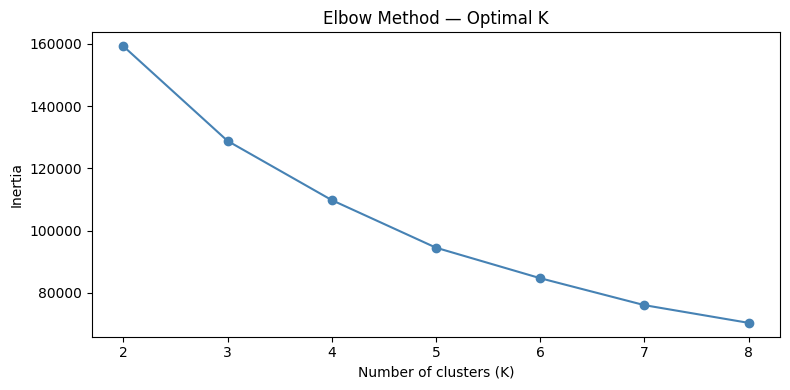

Inertias: {2: 159277.71328747287, 3: 128817.81841977221, 4: 109775.3524784444, 5: 94471.42523860007, 6: 84658.36112576246, 7: 75992.31509700623, 8: 70294.92421139903}


In [91]:
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal K")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

print("Inertias:", dict(zip(K_range, inertias)))

In [92]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
model_df['Segment'] = kmeans.fit_predict(X_cluster_scaled)

print("Segment distribution:")
print(model_df['Segment'].value_counts().sort_index())

print("\nSegment profiles (means):")
segment_profile = model_df.groupby('Segment')[CLUSTER_FEATURES].mean().round(1)
print(segment_profile)

Segment distribution:
Segment
0    13157
1    12965
2     8535
3    15343
Name: count, dtype: int64

Segment profiles (means):
         Customer_Age  Annual_Income  Credit_Score  Purchase_Amount
Segment                                                            
0                40.2        42443.1         475.6            290.3
1                41.3        96587.5         465.3            286.5
2                41.1        69896.8         584.3           1932.4
3                41.4        71159.1         743.1            269.5


In [93]:
# Let data decide the labels — never hardcode by number
print("Default rate per segment:")
seg_risk = {}
for seg in sorted(model_df['Segment'].unique()):
    seg_data     = model_df[model_df['Segment'] == seg]
    default_rate = (seg_data['Repayment_Status'] == 'Defaulted').mean()
    avg_credit   = seg_data['Credit_Score'].mean()
    avg_income   = seg_data['Annual_Income'].mean()
    avg_purchase = seg_data['Purchase_Amount'].mean()
    seg_risk[seg] = default_rate
    print(f"  Segment {seg}: Default={default_rate:.1%}  "
          f"Credit={avg_credit:.0f}  Income={avg_income:.0f}  "
          f"Purchase={avg_purchase:.0f}  n={len(seg_data)}")

# ── Sort segments by default rate → assign labels from worst to best
ranked = sorted(seg_risk, key=seg_risk.get, reverse=True)

# ranked[0] = highest default rate  → High Risk
# ranked[1] = second highest        → Medium Risk (poor credit, high income)
# ranked[2] = third                 → Watch (big spender)
# ranked[3] = lowest default rate   → Low Risk

SEGMENT_LABELS = {
    0: "High Risk",           # Low income + poor credit → 16.1% default
    1: "Watch — Poor Credit", # High income but credit score 465 → 8.9% default
    2: "Medium Risk",         # Big spender, fair credit → 9.2% default
    3: "Low Risk",            # Strong credit 743 → 2.1% default
}

print("\nFinal label mapping (data-driven):")
for seg, label in sorted(SEGMENT_LABELS.items()):
    print(f"  Segment {seg} → {label}  (default rate: {seg_risk[seg]:.1%})")

model_df['Segment_Label'] = model_df['Segment'].map(SEGMENT_LABELS)

print("\nSegment label distribution:")
print(model_df['Segment_Label'].value_counts())

# Verify — Defaulted customers should mostly be in High Risk
print("\nVerification — Repayment Status vs Segment Label:")
print(pd.crosstab(model_df['Segment_Label'],
                  model_df['Repayment_Status'],
                  normalize='index').round(3))

Default rate per segment:
  Segment 0: Default=16.1%  Credit=476  Income=42443  Purchase=290  n=13157
  Segment 1: Default=8.9%  Credit=465  Income=96587  Purchase=287  n=12965
  Segment 2: Default=9.2%  Credit=584  Income=69897  Purchase=1932  n=8535
  Segment 3: Default=2.1%  Credit=743  Income=71159  Purchase=269  n=15343

Final label mapping (data-driven):
  Segment 0 → High Risk  (default rate: 16.1%)
  Segment 1 → Watch — Poor Credit  (default rate: 8.9%)
  Segment 2 → Medium Risk  (default rate: 9.2%)
  Segment 3 → Low Risk  (default rate: 2.1%)

Segment label distribution:
Segment_Label
Low Risk               15343
High Risk              13157
Watch — Poor Credit    12965
Medium Risk             8535
Name: count, dtype: int64

Verification — Repayment Status vs Segment Label:
Repayment_Status     Defaulted  Late Payment  Paid On Time
Segment_Label                                             
High Risk                0.161         0.227         0.612
Low Risk                 0.0

In [94]:
joblib.dump(kmeans,         f"{MODEL_PATH}/kmeans.pkl")
joblib.dump(cluster_scaler, f"{MODEL_PATH}/kmeans_scaler.pkl")

# Also save segment label mapping
joblib.dump(SEGMENT_LABELS, f"{MODEL_PATH}/segment_labels.pkl")
print("Corrected labels saved.")

print("\nFinal distribution:")
print(model_df['Segment_Label'].value_counts())

print("K-Means models saved:")
print(f"  {MODEL_PATH}/kmeans.pkl")
print(f"  {MODEL_PATH}/kmeans_scaler.pkl")
print(f"  {MODEL_PATH}/segment_labels.pkl")

# Preview final model_df
print("\nmodel_df with segments:")
print(model_df[['Customer_Age','Annual_Income','Credit_Score',
                'Purchase_Amount','Repayment_Status',
                'Segment','Segment_Label']].head(10))

Corrected labels saved.

Final distribution:
Segment_Label
Low Risk               15343
High Risk              13157
Watch — Poor Credit    12965
Medium Risk             8535
Name: count, dtype: int64
K-Means models saved:
  /content/drive/MyDrive/BNPL/models/kmeans.pkl
  /content/drive/MyDrive/BNPL/models/kmeans_scaler.pkl
  /content/drive/MyDrive/BNPL/models/segment_labels.pkl

model_df with segments:
   Customer_Age  Annual_Income  Credit_Score  Purchase_Amount  \
0            56          32293           353              249   
1            46          72774           354              188   
2            32          82207           630             1610   
3            60          92498           470              120   
4            25          32060           502             1849   
5            38          94833           779             1112   
6            56          89772           403              418   
7            36          82341           731             2117   
8       

Early Warning Alert

In [95]:
# EARLY WARNING ALERT

syn_history = pd.read_excel(
    f"{DATA_PATH}/SIMULATED_BNPL_Customer_History.xlsx",
    sheet_name="Customer Behavioural Features",
    header=2        # ← skip the banner + subtitle rows, real headers are on row 3
)

# Fix the wrapped header names pandas reads with \n
syn_history.columns = syn_history.columns.str.replace('\n', ' ', regex=False).str.strip()

# Rename to clean column names your function expects
syn_history = syn_history.rename(columns={
    'Customer ID':              'Customer_ID',
    'Total Transactions':       'Total_Transactions',
    'Total Spending ($)':       'Total_Spending',
    'Avg Purchase Amount ($)':  'Avg_Purchase_Amount',
    'Max Purchase Amount ($)':  'Max_Purchase_Amount',
    'Purchase Freq (per month)':'Purchase_Frequency_per_Month',
    'On-Time Rate':             'On_Time_Payment_Rate',
    'Late Rate':                'Late_Payment_Rate',
    'Default Rate':             'Default_Rate',
    'Avg Days to Repay':        'Avg_Days_to_Repay',
    'Max Days to Repay':        'Max_Days_to_Repay',
    'Spend Trend (slope)':      'Recent_Spend_Trend',
    'Days Since Last Purchase':  'Days_Since_Last_Purchase',
    'Bad Payments (Last 3)':    'Recent_Bad_Payments_Last3',
    'Most Used Category':       'Most_Used_Category',
    'BNPL Provider':            'BNPL_Provider',
})

print("Columns after fix:", syn_history.columns.tolist())
print("Shape:", syn_history.shape)
print("First Customer_ID:", syn_history['Customer_ID'].iloc[0])

Columns after fix: ['Customer_ID', 'Archetype', 'Total_Transactions', 'Total_Spending', 'Avg_Purchase_Amount', 'Max_Purchase_Amount', 'Purchase_Frequency_per_Month', 'On_Time_Payment_Rate', 'Late_Payment_Rate', 'Default_Rate', 'Avg_Days_to_Repay', 'Max_Days_to_Repay', 'Recent_Spend_Trend', 'Days_Since_Last_Purchase', 'Recent_Bad_Payments_Last3', 'Most_Used_Category', 'BNPL_Provider']
Shape: (50, 17)
First Customer_ID: CUST_1001


In [96]:
def early_warning_check(customer_id: str, syn_history: pd.DataFrame) -> dict:
    """
    Checks behavioural signals from transaction history.
    Returns alert status + specific triggers.

    Fires 🔴 ALERT if ANY 2 of 3 conditions are true:
        1. Recent spend trend is rising (slope > 20)
        2. Default or late rate is worsening (On_Time_Payment_Rate < 0.60)
        3. Recent bad payments in last 3 transactions >= 1
    """
    row = syn_history[syn_history['Customer_ID'] == customer_id]

    # Customer not in synthetic history — no behavioural data yet
    if row.empty:
        return {
            "alert_status":  "No History",
            "alert_triggers": [],
            "alert_message":  "No transaction history available for this customer.",
            "behavioural_summary": {}
        }

    row = row.iloc[0]

    triggers  = []
    conditions_met = 0

    # ── Condition 1: Rising spend trend ─────────────────────────
    spend_trend = row['Recent_Spend_Trend']
    if spend_trend > 20:
        conditions_met += 1
        triggers.append(f"Spending is rising (trend slope: +{spend_trend:.1f})")

    # ── Condition 2: Low on-time payment rate ───────────────────
    ontime_rate = row['On_Time_Payment_Rate']
    if ontime_rate < 0.60:
        conditions_met += 1
        triggers.append(f"On-time payment rate is low ({ontime_rate:.0%})")

    # ── Condition 3: Recent bad payments ────────────────────────
    recent_bad = row['Recent_Bad_Payments_Last3']
    if recent_bad >= 1:
        conditions_met += 1
        triggers.append(f"{int(recent_bad)} bad payment(s) in last 3 transactions")

    # ── Final alert status ───────────────────────────────────────
    if conditions_met >= 2:
        alert_status  = "ALERT — Behaviour Deteriorating"
        alert_message = "This customer shows multiple warning signals. Consider reducing credit limit."
    elif conditions_met == 1:
        alert_status  = "WATCH — Monitor Closely"
        alert_message = "One warning signal detected. Continue monitoring."
    else:
        alert_status  = "CLEAR — Behaviour Stable"
        alert_message = "No behavioural warning signals detected."

    return {
        "alert_status":   alert_status,
        "alert_triggers": triggers,
        "alert_message":  alert_message,
        "behavioural_summary": {
            "total_transactions":        int(row['Total_Transactions']),
            "avg_purchase_amount":       round(row['Avg_Purchase_Amount'], 2),
            "on_time_rate":              round(ontime_rate, 3),
            "late_payment_rate":         round(row['Late_Payment_Rate'], 3),
            "default_rate":              round(row['Default_Rate'], 3),
            "avg_days_to_repay":         round(row['Avg_Days_to_Repay'], 1),
            "recent_spend_trend":        round(spend_trend, 2),
            "days_since_last_purchase":  int(row['Days_Since_Last_Purchase']),
            "recent_bad_payments_last3": int(recent_bad),
        }
    }


# ── Test on 3 synthetic customers ────────────────────────────────
test_ids = ['CUST_1001', 'CUST_1011', 'CUST_1021']

print("=" * 60)
print("EARLY WARNING ALERT TEST")
print("=" * 60)

for cid in test_ids:
    result = early_warning_check(cid, syn_history)
    print(f"\nCustomer: {cid}")
    print(f"  Status   : {result['alert_status']}")
    print(f"  Message  : {result['alert_message']}")
    if result['alert_triggers']:
        print(f"  Triggers :")
        for t in result['alert_triggers']:
            print(f"    ⚠ {t}")
    if result['behavioural_summary']:
        bs = result['behavioural_summary']
        print(f"  On-Time  : {bs['on_time_rate']:.0%}  "
              f"Late: {bs['late_payment_rate']:.0%}  "
              f"Default: {bs['default_rate']:.0%}")
        print(f"  Trend    : {bs['recent_spend_trend']:+.1f}  "
              f"Bad last 3: {bs['recent_bad_payments_last3']}")

EARLY WARNING ALERT TEST

Customer: CUST_1001
  Status   : WATCH — Monitor Closely
  Message  : One warning signal detected. Continue monitoring.
  Triggers :
    ⚠ Spending is rising (trend slope: +35.7)
  On-Time  : 90%  Late: 10%  Default: 0%
  Trend    : +35.7  Bad last 3: 0

Customer: CUST_1011
  Status   : ALERT — Behaviour Deteriorating
  Message  : This customer shows multiple warning signals. Consider reducing credit limit.
  Triggers :
    ⚠ Spending is rising (trend slope: +44.1)
    ⚠ On-time payment rate is low (10%)
    ⚠ 3 bad payment(s) in last 3 transactions
  On-Time  : 10%  Late: 80%  Default: 10%
  Trend    : +44.1  Bad last 3: 3

Customer: CUST_1021
  Status   : WATCH — Monitor Closely
  Message  : One warning signal detected. Continue monitoring.
  Triggers :
    ⚠ 2 bad payment(s) in last 3 transactions
  On-Time  : 70%  Late: 30%  Default: 0%
  Trend    : -45.4  Bad last 3: 2


In [97]:
# ── Check all 50 synthetic customers ────────────────────────────
all_alerts = []

for cid in syn_history['Customer_ID'].unique():
    result = early_warning_check(cid, syn_history)
    all_alerts.append({
        "Customer_ID":   cid,
        "Alert_Status":  result['alert_status'],
        "Triggers":      " | ".join(result['alert_triggers']),
        **result['behavioural_summary']
    })

alerts_df = pd.DataFrame(all_alerts)

print("Alert distribution across 50 customers:")
print(alerts_df['Alert_Status'].value_counts())

print("\nCustomers with ALERT status:")
alert_customers = alerts_df[alerts_df['Alert_Status'].str.contains('ALERT')]
print(alert_customers[['Customer_ID','Alert_Status','on_time_rate',
                        'recent_spend_trend','recent_bad_payments_last3',
                        'Triggers']].to_string())

# Save
alerts_df.to_csv(f"{OUTPUT_PATH}/early_warning_alerts.csv", index=False)
joblib.dump(early_warning_check, f"{MODEL_PATH}/early_warning_fn.pkl")
print("\nEarly warning outputs saved.")

Alert distribution across 50 customers:
Alert_Status
ALERT — Behaviour Deteriorating    29
WATCH — Monitor Closely            12
CLEAR — Behaviour Stable            9
Name: count, dtype: int64

Customers with ALERT status:
   Customer_ID                     Alert_Status  on_time_rate  recent_spend_trend  recent_bad_payments_last3                                                                                                                Triggers
10   CUST_1011  ALERT — Behaviour Deteriorating           0.1                44.1                          3   Spending is rising (trend slope: +44.1) | On-time payment rate is low (10%) | 3 bad payment(s) in last 3 transactions
11   CUST_1012  ALERT — Behaviour Deteriorating           0.1               -25.5                          3                                             On-time payment rate is low (10%) | 3 bad payment(s) in last 3 transactions
12   CUST_1013  ALERT — Behaviour Deteriorating           0.2               -25.4         

Full integration test


In [98]:
# ── FULL INTEGRATION TEST — all layers together ──────────────────

def full_bnpl_assessment(customer_input: dict, syn_history: pd.DataFrame) -> dict:
    """
    Runs all 6 layers for a single customer.
    This is the exact function your Streamlit app will call.
    """

    # ── Layer 1: Fraud check ─────────────────────────────────────
    fraud_input = {
        "Shared_Device_Accounts":  customer_input.get("Shared_Device_Accounts", 1),
        "Shared_Payment_Accounts": customer_input.get("Shared_Payment_Accounts", 1),
        "Account_Age_Days":        customer_input.get("Account_Age_Days", 365),
        "Identity_Mismatch":       customer_input.get("Identity_Mismatch", False),
        "Unusual_Device":          customer_input.get("Unusual_Device", False),
        "First_Party_Fraud_Signal":customer_input.get("First_Party_Fraud_Signal", False),
    }
    fraud_result = fraud_check(fraud_input)

    # ── Layers 3+4+5: ML prediction + segment + scoring ──────────
    ml_result = predict_customer(customer_input)

    # ── Layer 6: Early warning ────────────────────────────────────
    ew_result = early_warning_check(
        customer_input.get("Customer_ID", ""),
        syn_history
    )

    return {
        # Layer 1
        "fraud_score":        fraud_result["fraud_score"],
        "fraud_status":       fraud_result["status"],
        "fraud_alerts":       fraud_result["alerts"],
        # Layer 3
        "segment":            ml_result["segment"],
        # Layer 4+5
        "default_probability":ml_result["default_probability"],
        "risk_level":         ml_result["risk_level"],
        "risk_score":         ml_result["risk_score"],
        "credit_limit":       ml_result["credit_limit"],
        "top_risk_factors":   ml_result["top_risk_factors"],
        # Layer 6
        "alert_status":       ew_result["alert_status"],
        "alert_triggers":     ew_result["alert_triggers"],
        "alert_message":      ew_result["alert_message"],
        "behavioural_summary":ew_result["behavioural_summary"],
    }


# ── Run test ─────────────────────────────────────────────────────
test_customer = {
    # Identity
    "Customer_ID":              "CUST_1011",   # repeat defaulter in syn history
    # ML features
    "Customer_Age":             34,
    "Annual_Income":            38000,
    "Credit_Score":             420,
    "Purchase_Amount":          1500,
    "Gender":                   "Male",
    "Purchase_Category":        "Electronics",
    "BNPL_Provider":            "Klarna",
    # Fraud signals
    "Shared_Device_Accounts":   3,
    "Shared_Payment_Accounts":  1,
    "Account_Age_Days":         22,
    "Identity_Mismatch":        False,
    "Unusual_Device":           True,
    "First_Party_Fraud_Signal": False,
}

output = full_bnpl_assessment(test_customer, syn_history)

print("=" * 55)
print("FULL BNPL ASSESSMENT — CUST_1011")
print("=" * 55)

print(f"\n[LAYER 1 — FRAUD]")
print(f"  Score   : {output['fraud_score']}")
print(f"  Status  : {output['fraud_status']}")
print(f"  Alerts  : {output['fraud_alerts']}")

print(f"\n[LAYER 3 — SEGMENT]")
print(f"  Segment : {output['segment']}")

print(f"\n[LAYER 4+5 — ML + SCORING]")
print(f"  Default Prob  : {output['default_probability']:.1%}")
print(f"  Risk Level    : {output['risk_level']}")
print(f"  Risk Score    : {output['risk_score']} / 100")
print(f"  Credit Limit  : ₹{output['credit_limit']:,.0f}")
print(f"  Top Factors   : {output['top_risk_factors'][:3]}")

print(f"\n[LAYER 6 — EARLY WARNING]")
print(f"  Status  : {output['alert_status']}")
print(f"  Message : {output['alert_message']}")
for t in output['alert_triggers']:
    print(f"  ⚠ {t}")

if output['behavioural_summary']:
    bs = output['behavioural_summary']
    print(f"\n  Behaviour Summary:")
    print(f"    On-Time Rate    : {bs['on_time_rate']:.0%}")
    print(f"    Avg Days Repay  : {bs['avg_days_to_repay']}")
    print(f"    Spend Trend     : {bs['recent_spend_trend']:+.1f}")
    print(f"    Bad (Last 3)    : {bs['recent_bad_payments_last3']}")


FULL BNPL ASSESSMENT — CUST_1011

[LAYER 1 — FRAUD]
  Score   : 35
  Status  : REVIEW
  Alerts  : ['Very new account', 'Unusual device activity']

[LAYER 3 — SEGMENT]
  Segment : Medium Risk

[LAYER 4+5 — ML + SCORING]
  Default Prob  : 55.7%
  Risk Level    : HIGH
  Risk Score    : 47.0 / 100
  Credit Limit  : ₹1,000
  Top Factors   : ['numeric__Purchase_Amount', 'numeric__Annual_Income', 'numeric__Credit_Score']

[LAYER 6 — EARLY WARNING]
  Status  : ALERT — Behaviour Deteriorating
  Message : This customer shows multiple warning signals. Consider reducing credit limit.
  ⚠ Spending is rising (trend slope: +44.1)
  ⚠ On-time payment rate is low (10%)
  ⚠ 3 bad payment(s) in last 3 transactions

  Behaviour Summary:
    On-Time Rate    : 10%
    Avg Days Repay  : 38.0
    Spend Trend     : +44.1
    Bad (Last 3)    : 3
